### Persistence

In this we will be implimenting the code for 
1) In-memory persistence
2) Fault tolerence using persistence
3) Time Travel using persistence

### Problem Statement

Build a **persistence-enabled workflow using LangGraph in Python** that generates and explains a joke.

The workflow should:

1. Accept a user request for a joke.
2. Generate a joke based on the request.
3. Explain the generated joke.
4. Use **LangGraph persistence/checkpointing** to save the state of the workflow.
5. Allow the workflow state to be persisted so that the conversation can be resumed or inspected later.
6. End after returning both the **joke** and its **explanation**.

**Workflow:**

```text
START → Generate Joke → Explain Joke → END
```


In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
# Import of persistence
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(model='gpt-5.4-mini', max_completion_tokens=300)

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    joke_expl: str

In [6]:
def generate_joke(state: JokeState) -> JokeState:
    topic = state['topic']

    joke = model.invoke(f"Give me joke on topic {topic}.").content

    return {'joke': joke}

In [7]:
def explain_joke(state: JokeState) -> JokeState:
    topic = state['topic']
    joke = state['joke']
    expl = model.invoke(f"explain the joke {joke} on topic {topic}.").content

    return {'joke_expl': expl}

In [8]:
graph = StateGraph(JokeState)

In [9]:
# Graph Nodes
graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

# Graph Edges
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

# Memory
memory = InMemorySaver()

# Compile Graph
workflow = graph.compile(checkpointer=memory)

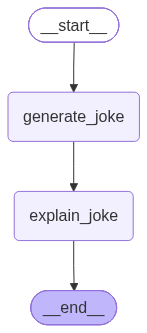

In [10]:
workflow

In [11]:
# Create thread config for identifying the chat
config = {'configurable': {'thread_id': 1}}

input_state = {"topic": "Pizza"}

res = workflow.invoke(input=input_state, config=config)

In [12]:
res

{'topic': 'Pizza',
 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough.',
 'joke_expl': 'The joke is a pun on the word **“dough.”**\n\n- **Dough** is the raw mixture used to make pizza crust.\n- **Dough** also means **money** in slang.\n\nSo the punchline says the pizza maker went broke because he couldn’t make enough **dough** — meaning he couldn’t earn enough money. The humor comes from the double meaning, and it fits the topic of **pizza** because pizza makers work with dough all the time.'}

In [13]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza maker go broke?\n\nBecause he just couldn’t make enough dough.', 'joke_expl': 'The joke is a pun on the word **“dough.”**\n\n- **Dough** is the raw mixture used to make pizza crust.\n- **Dough** also means **money** in slang.\n\nSo the punchline says the pizza maker went broke because he couldn’t make enough **dough** — meaning he couldn’t earn enough money. The humor comes from the double meaning, and it fits the topic of **pizza** because pizza makers work with dough all the time.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19b47c-c55c-68f2-8002-26d09f3d2810'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T21:00:09.835289+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19b47c-b4df-667a-8001-6de81e767785'}}, tasks=(), interrupts=())

### Problem Statement

Build a **fault-tolerant workflow using LangGraph persistence** that demonstrates how a workflow can be interrupted and resumed without losing its previous state.

The workflow should contain three sequential steps:

1. **Step 1:** Perform an initial task and save its result.
2. **Step 2:** Perform a task that takes **30 seconds** to complete. During this step, manually interrupt the program using the keyboard (`Ctrl+C`).
3. **Step 3:** Continue processing after Step 2.

Use **LangGraph persistence/checkpointing** so that after the interruption, the workflow can be **resumed from the saved state** rather than starting again from Step 1.

**Workflow:**

```text
START → Step 1 → Step 2 (30 sec) → Step 3 → END
                         ↓
                    Ctrl+C
                         ↓
              Resume from checkpoint
                         ↓
                    Step 2/3 → END
```

**Objective:** Demonstrate how LangGraph persistence provides **fault tolerance and recovery from an interrupted workflow**.


In [9]:
import time
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
# Import of persistence
from langgraph.checkpoint.memory import InMemorySaver

In [10]:
class FTState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [11]:
def step1(state: FTState) -> FTState:
    print("Running step1....")
    print("step1 completed.")
    return {'step1': 'done'}

In [27]:
def step2(state: FTState) -> FTState:
    print("Running step2....")
    try:
        time.sleep(3)
        if True:
            raise KeyboardInterrupt
            return
    except KeyboardInterrupt:
        print('Interrupted at step2 by user :(')
        
    print("step2 completed.")
    return {'step2': 'done'}

In [28]:
def step3(state: FTState) -> FTState:
    print("Running step3....")
    print("step3 completed.")
    return {'step3': 'done'}

In [34]:
graph1 = StateGraph(FTState)

In [35]:
graph1.add_node('step1', step1)
graph1.add_node('step2', step2)
graph1.add_node('step3', step3)


graph1.add_edge(START, 'step1')
graph1.add_edge('step1', 'step2')
graph1.add_edge('step2', 'step3')
graph1.add_edge('step3', END)

memory = InMemorySaver()

workflow1 = graph1.compile(checkpointer=memory, interrupt_before=["step2"])

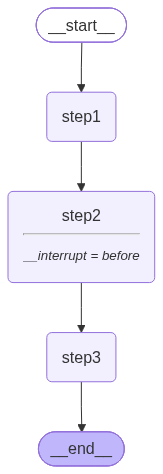

In [36]:
workflow1

In [37]:
config = {'configurable': {'thread_id': 1}}

input_state = {'input': "start"}
try:
    workflow1.invoke(input_state, config=config)
except KeyboardInterrupt:
    print('Interrupted by user.')

Running step1....
step1 completed.


In [38]:
# current state after interruption
workflow1.get_state(config)

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19b48b-d4ed-6ded-8001-39ee5550e5fa'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-18T21:06:54.120894+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19b48b-d4ea-6c16-8000-ccd37d145256'}}, tasks=(PregelTask(id='85f42222-59db-1204-e9d5-9622b4618519', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [39]:
# Continue on the interrupted step
workflow1.invoke(None, config={'configurable': {'thread_id': 1, 'checkpoint_id': '1f19b48b-d4ed-6ded-8001-39ee5550e5fa'}})

Running step2....
Interrupted at step2 by user :(
step2 completed.
Running step3....
step3 completed.


{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}